In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))
res='1km'

# #uncomment if using 250m data
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [ ]:
#RESIDENCE CODE
########################################################################################################################

In [ ]:
#READING DATA BACK IN LATER

In [3]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [ ]:
#CALCULATING RESIDENCE TIMES
#############################

In [ ]:
# B=np.array([0,1,0,1,0,1,1,0,0,1,1])

# # B=1-B #for detrainment, otherwise do comment out
# print(f'binary {B}')
# cat=np.concatenate(([0], B, [0]))
# # print(f'cat {cat}')
# diff=np.diff(cat)
# print(f'diff {diff}')

In [ ]:
# #CODE FOR SUBSETTING DRY ENTRAINMENT
# ind=0

# row=out_nz[ind]
# out=residence_times(row[0],'e')
# where=np.where((out[5]<=3)&(out[5]!=-100000))

# A[out[1][where],row[0]] #set to 0 

In [4]:
def residence_times(p,type,updraft_type):

    if updraft_type=='general':
        A=A_g
    elif updraft_type=='cloudy':
        A=A_c
    
    B = A[:,p]

    # B=np.array([0,1,0,1,0,0,1,1,0,1,1]) #TESTING
    
    T=np.arange(len(B))
    
    if np.any(B)==True:
        if type=='e':
            C=B.copy()
        elif type=='d':
            C=1-B
    
        
        # Find the changes in the array
        changes = np.diff(np.concatenate(([0], C, [0])))  # Add 0s to detect edges
            
        start_ind = np.where(changes == 1)[0]  # Start of sequences
        end_ind = np.where(changes == -1)[0]  # End of sequences
        
        # Calculate the lengths of sequences
        lengths = end_ind - start_ind

        sequences = [(start) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1] #only records en/detrainment time
        # sequences = [(start, *range(start + 1, end+1)) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1]
        lens=[(end-start) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1] #residence times

        #Remove the last one to get rid of entrainments that reach end of simulation
        sequences=sequences[:-1];lens=lens[:-1]

        #Initial Entrainment/Detrainment Times
        ts=np.array(sequences.copy()) #only records en/detrainment time 
        # ts=np.array(tuple(item for seq in sequences for item in seq))

         #Finds Last Time Parcel is in Cloudy Updraft before Inital Entrainment
        last=[None]+[np.where(C[:ind + 1] == 1)[0][-2] for ind in ts[1:]]
        last_lens=ts[1:]-last[1:]; last_lens=np.insert(last_lens, 0, -1e5)

        if np.any(ts):
            zs=Z[ts,p]
            ys=Y[ts,p]
            xs=X[ts,p]
            return [np.array(lens),ts,zs,ys,xs,last_lens]
        else:
            return []
    else:
        return []

p=42483; out=residence_times(p,type='e',updraft_type='cloudy')
out


[array([2, 1]),
 array([ 8, 11]),
 array([ 8, 12]),
 array([68, 68]),
 array([348, 349]),
 array([-100000,       2])]

In [ ]:
# #TORRI 2015 TESTING TESTING TESTING
# Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
# xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
# xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

# Np=125000-1
# for p in np.arange(Np): 
#     out=residence_times(p,type='e')
#     if np.any(out):
#         xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
#         xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        
#         xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
#         xz_counter[out[2],out[4]]+=np.ones_like(out[0])


# one=xz_array.flatten()
# two=xz_counter.flatten()

# #SORTING
# sorted_indices = np.argsort(two)
# sorted_two = two[sorted_indices]
# sorted_one = one[sorted_indices]

# plt.plot(sorted_one,sorted_two*100/(np.sum(xz_counter)))
# plt.ylabel('% Fraction of particles');plt.xlabel('Residence Times (mins)')
# plt.title("Testing")

In [5]:
#ENTRAINMENT/DETRAINMENT PROFILES
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
    out=residence_times(p,type='e',updraft_type='cloudy')
    

    if np.any(out):
        # #TESTING. ONLY STORING PRECONDITIONS PARCELS
        # for ind in np.arange(6):
        #     out[ind]=out[ind][np.where(out[-1]<=2)]
        # #####

        # xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        # xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        np.add.at(xy_array, (out[3], out[4]), out[0])  
        np.add.at(xy_counter, (out[3], out[4]), 1)
        
        # xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        # xz_counter[out[2],out[4]]+=np.ones_like(out[0])
        np.add.at(xz_array, (out[2], out[4]), out[0])  # Add residence times to (x, z) positions
        np.add.at(xz_counter, (out[2], out[4]), 1)


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]

#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

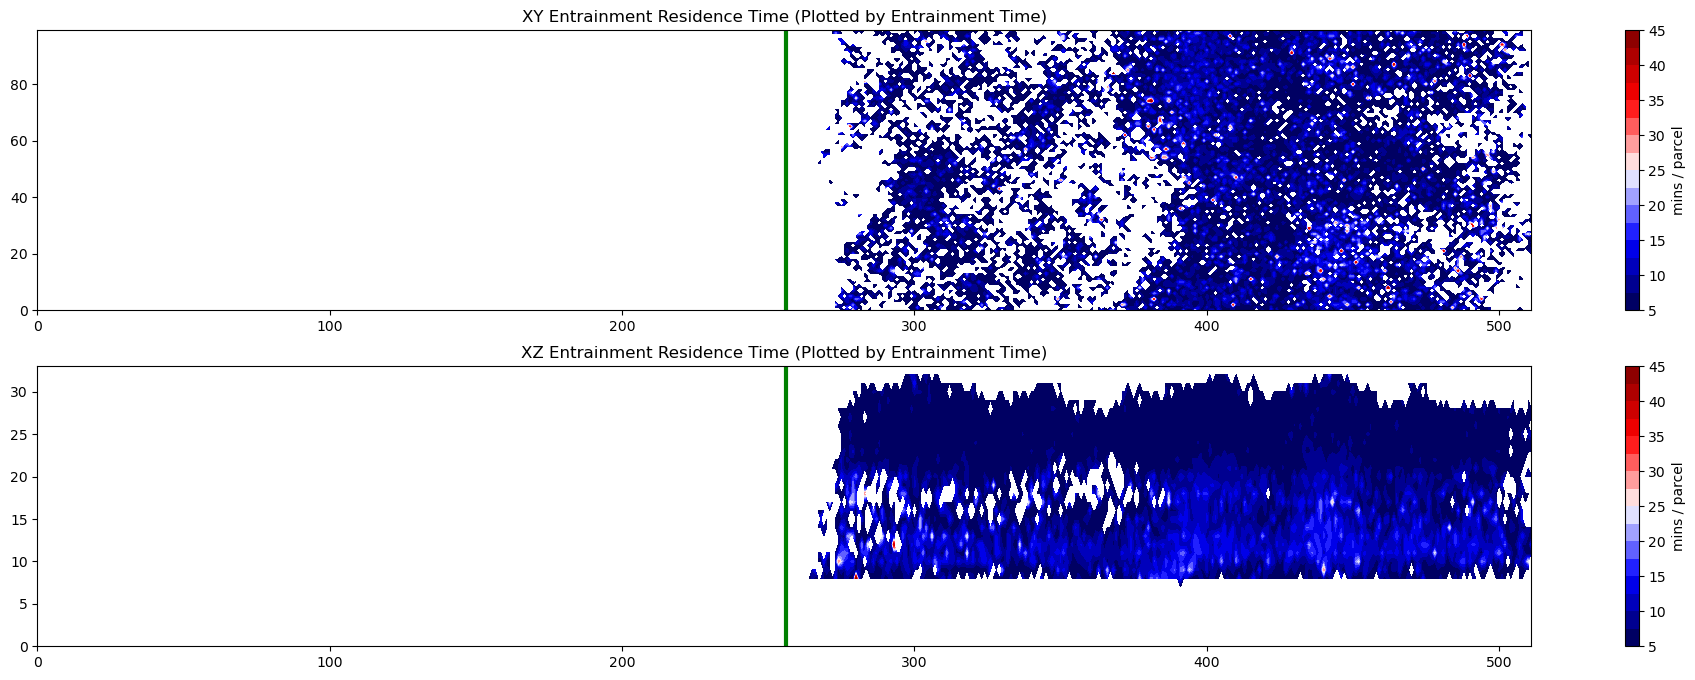

In [6]:
xy_array[xy_array==0]=np.nan
xz_array[xz_array==0]=np.nan

fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Entrainment Residence Time (Plotted by Entrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Entrainment Residence Time (Plotted by Entrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



/tmp/ipykernel_542334/1622528860.py:9: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')


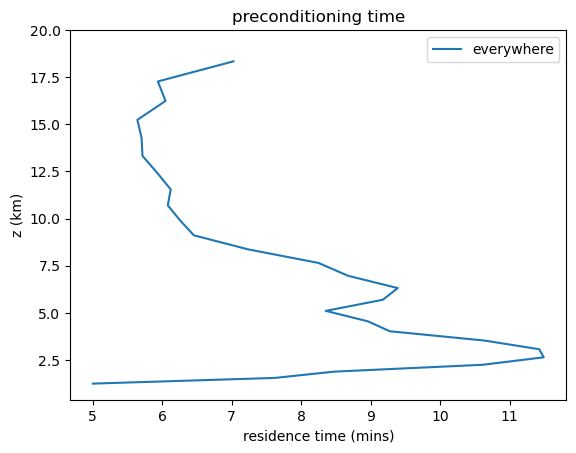

In [7]:
# currently i look for runs of being in cloudy updraft that are at least 5 minutes (1 timestep). i add the total length of that run at the location of initial entrainment/detrainment. then i average to get vertical profile. 

# For entrainment, particles should stay in a cloud for 30/60 minutes
# I’m very surprised by a) the extremely low values for entrainment time and b) the extremely high values for detainment times
# another thing: this is only cloudy updrafts, not clouds as well. is that 30/60 minutes true for the “cloud updrafts”?
# for detrainment then, there are some parcels that don’t interact with any “cloudy updrafts” for a very long time.
# also, if you look at the contour plot we do have higher values than the vertical profile 

plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')
plt.ylabel('z (km)');plt.xlabel('residence time (mins)')


# plt.plot(np.nanmean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

# plt.plot(np.nanmean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

plt.ylim(top=20)
plt.title('preconditioning time')
plt.legend()

In [8]:
#PRECONDITIONING TIMES
#ENTRAINMENT/DETRAINMENT PROFILES
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
# for p in out_nz[:,0]: #FOR OUT_NZ
    out=residence_times(p,type='e',updraft_type='cloudy')
    

    if np.any(out):
        out=[arr[1:] for arr in out] #TESTING

        #TESTING. ONLY STORING PRECONDITIONS PARCELS
        # for ind in np.arange(6):
        #     out[ind]=out[ind][np.where(out[-1]<=2)]
        ######

        # xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        # xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        np.add.at(xy_array, (out[3], out[4]), out[-1])  
        np.add.at(xy_counter, (out[3], out[4]), 1)
        
        # xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        # xz_counter[out[2],out[4]]+=np.ones_like(out[0])
        np.add.at(xz_array, (out[2], out[4]), out[-1])  # Add residence times to (x, z) positions
        np.add.at(xz_counter, (out[2], out[4]), 1)


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]

#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

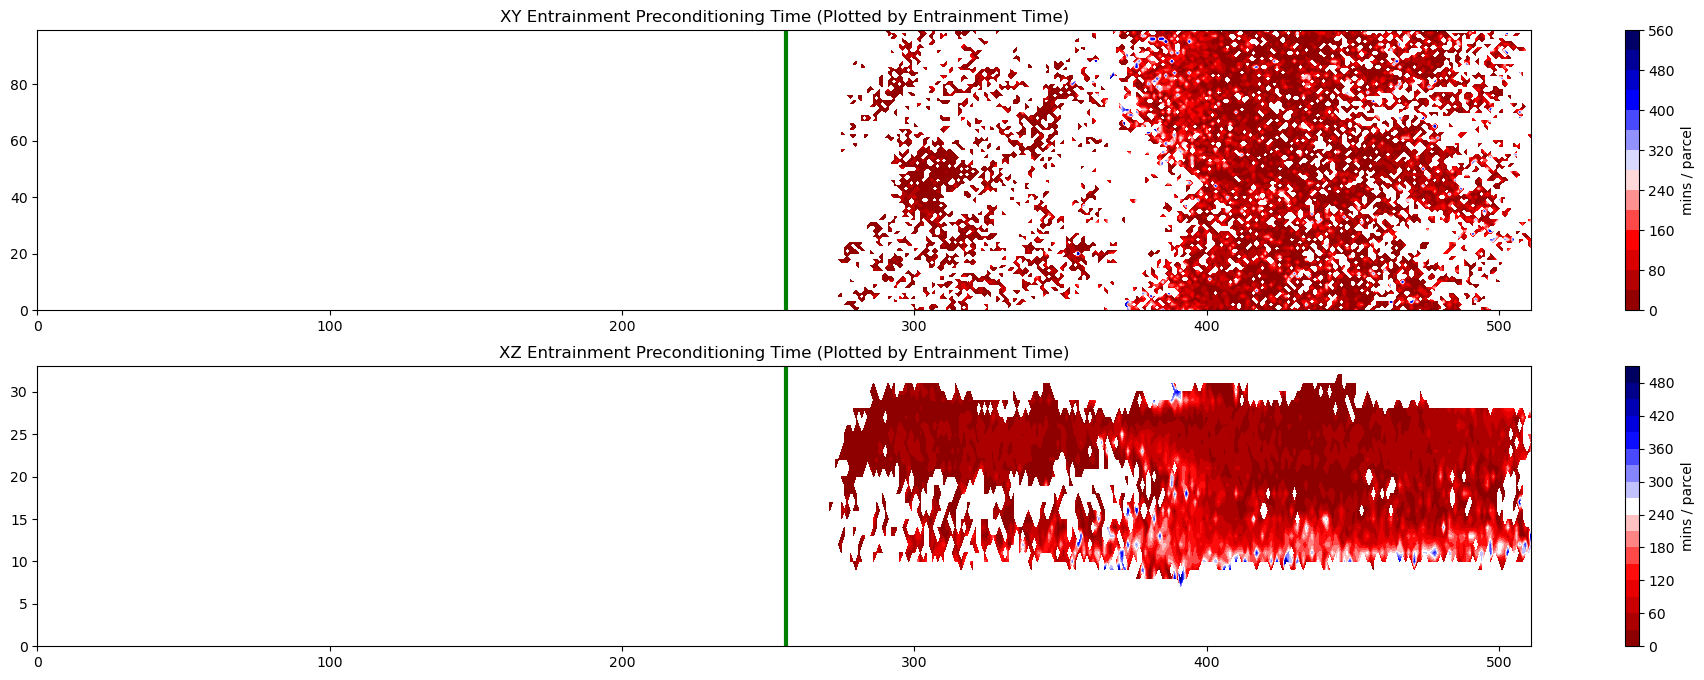

In [9]:
xy_array[xy_array==0]=np.nan
xz_array[xz_array==0]=np.nan

fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic_r'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Entrainment Preconditioning Time (Plotted by Entrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Entrainment Preconditioning Time (Plotted by Entrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



/tmp/ipykernel_542334/956800355.py:9: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')


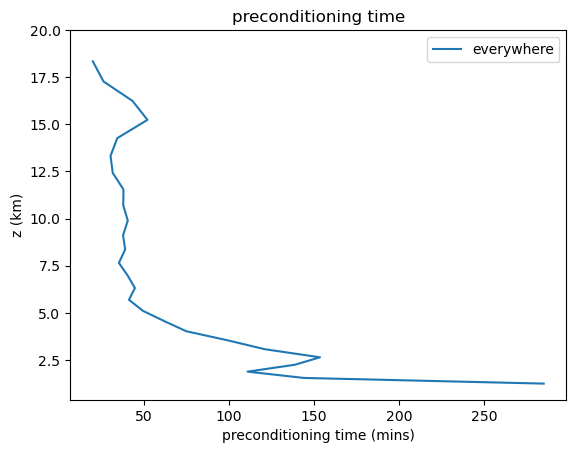

In [10]:
# currently i look for runs of being in cloudy updraft that are at least 5 minutes (1 timestep). i add the total length of that run at the location of initial entrainment/detrainment. then i average to get vertical profile. 

# For entrainment, particles should stay in a cloud for 30/60 minutes
# I’m very surprised by a) the extremely low values for entrainment time and b) the extremely high values for detainment times
# another thing: this is only cloudy updrafts, not clouds as well. is that 30/60 minutes true for the “cloud updrafts”?
# for detrainment then, there are some parcels that don’t interact with any “cloudy updrafts” for a very long time.
# also, if you look at the contour plot we do have higher values than the vertical profile 

plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')
plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')


# plt.plot(np.nanmean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

# plt.plot(np.nanmean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

plt.ylim(top=20)
plt.title('preconditioning time')
plt.legend()

In [ ]:
# #TESTING TESTING TESTING *&*&*&*&
# #PRECONDITION FOR CL INTERACTION 


# #MAKE PROFILE ARRAY
# zhs=data['zh'].values
# profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
# profile_array[:,2]=zhs

# #COMPUTE
# mins=((data['time'][1]-data['time'][0])/1e9/60).item()
# for ind in np.arange(out_nz.shape[0]):
#     row=out_nz[ind]
    
#     previous=A[:,row[0]][:row[4]]
#     CL_z=Z[row[4],row[0]]
#     if np.any(previous)==True:
#         last=np.where(previous==1)[0][-1]
#         last_len=row[4]-last
#         last_len_mins=last_len*mins
        
#         #ADD TO PROFILE ARRAY
#         profile_array[CL_z,0]+=last_len*mins
#         profile_array[CL_z,1]+=1

    
#    #*&*&

# def averaged_profiles(profile): 
#     out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
#     out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
#     return out_var
# avg_profile_array=averaged_profiles(profile_array)

# plt.plot(avg_profile_array[:,0],avg_profile_array[:,1]*1000)
# plt.xlabel('t (mins)');plt.ylabel('z (m)')
# plt.title('Testing. When was parcel last in cloudy updraft before hitting CL')

In [11]:
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
    out=residence_times(p,type='d',updraft_type='cloudy')
    if np.any(out):
        
        # xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        # xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        np.add.at(xy_array, (out[3], out[4]), out[0])  
        np.add.at(xy_counter, (out[3], out[4]), 1)
        
        # xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        # xz_counter[out[2],out[4]]+=np.ones_like(out[0])
        np.add.at(xz_array, (out[2], out[4]), out[0])  # Add residence times to (x, z) positions
        np.add.at(xz_counter, (out[2], out[4]), 1)


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]


#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

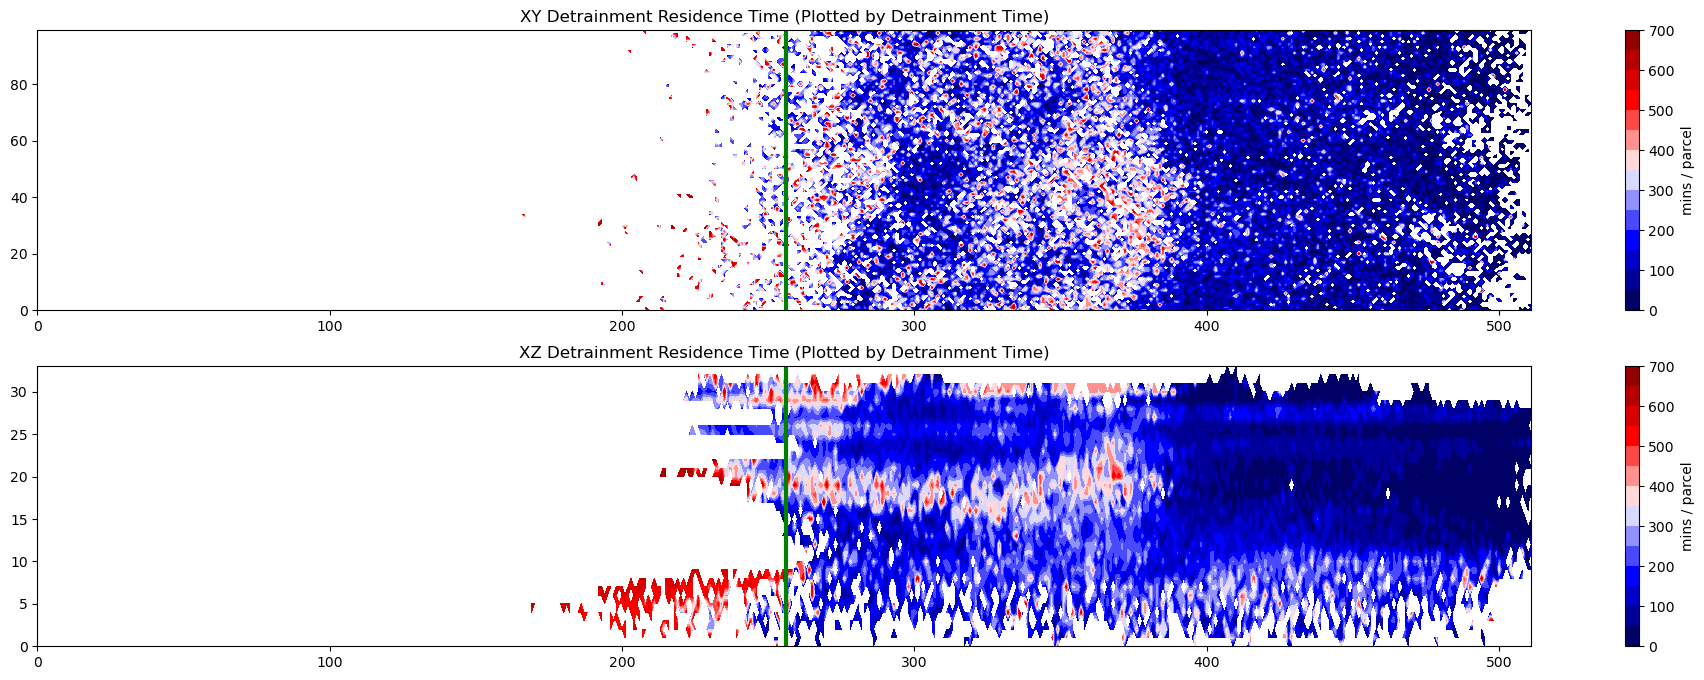

In [12]:
xy_array[xy_array==0]=np.nan
xz_array[xz_array==0]=np.nan

fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Detrainment Residence Time (Plotted by Detrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Detrainment Residence Time (Plotted by Detrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



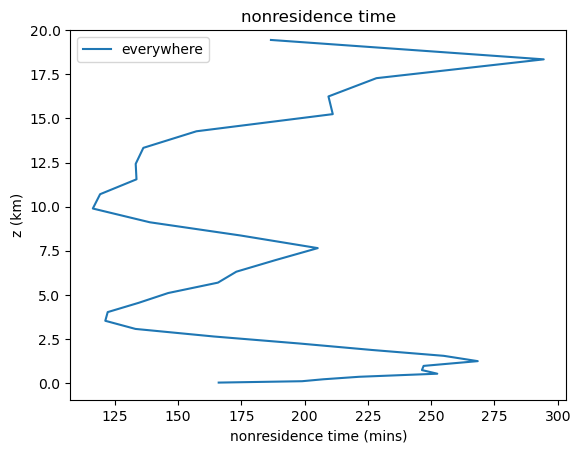

In [13]:
# currently i look for runs of being in cloudy updraft that are at least 5 minutes (1 timestep). i add the total length of that run at the location of initial entrainment/detrainment. then i average to get vertical profile. 

# For entrainment, particles should stay in a cloud for 30/60 minutes
# I’m very surprised by a) the extremely low values for entrainment time and b) the extremely high values for detainment times
# another thing: this is only cloudy updrafts, not clouds as well. is that 30/60 minutes true for the “cloud updrafts”?
# for detrainment then, there are some parcels that don’t interact with any “cloudy updrafts” for a very long time.
# also, if you look at the contour plot we do have higher values than the vertical profile 

plt.plot(np.nanmean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')
plt.ylabel('z (km)');plt.xlabel('nonresidence time (mins)')


# plt.plot(np.nanmean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

# plt.plot(np.nanmean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')
# plt.ylabel('z (km)');plt.xlabel('preconditioning time (mins)')

plt.ylim(top=20)
plt.title('nonresidence time')
plt.legend()

In [ ]:
#IMPORTANT FOR PLOTTING

# xticks/yticks
# xticks = plt.gca().get_xticks()
# new_labels = [str(int(tick * 5)) for tick in xticks]
# plt.gca().set_xticklabels(new_labels);

# cbar-ticks
# cbar_ticks = cbar.get_ticks()  # Get the current ticks
# new_ticks = [str(int(tick * 5)) for tick in cbar_ticks]  # Modify ticks (multiply by 5 and convert to string)
# cbar.set_ticks(cbar_ticks)  # Set the original ticks again to avoid resetting
# cbar.set_ticklabels(new_ticks)


#imshow
# plt.yticks(np.arange(Nz))
# new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
# plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)

In [ ]:
#MAKING 2D HISTOGRAM OF RESIDENCE TIME VS Z (COLOR: VARIABLE)

In [14]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [15]:
lst=[]
for p in np.arange(Np):
    out=residence_times(p,type='e',updraft_type='cloudy')
    if np.any(out)==True:
        lens=out[0]
        lst.append(lens)
print(f'max entrainment time: {max(arr.max() for arr in lst)}')

max entrainment time: 13


In [16]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e',updraft_type='cloudy')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=1

# #NORMALIZATION
row_averages = np.nansum(profile, axis=1)
mask = row_averages!=0
profile[mask] /= row_averages[mask,np.newaxis]


In [17]:
# one=profile.copy()
two=profile.copy()

/tmp/ipykernel_542334/3155184634.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


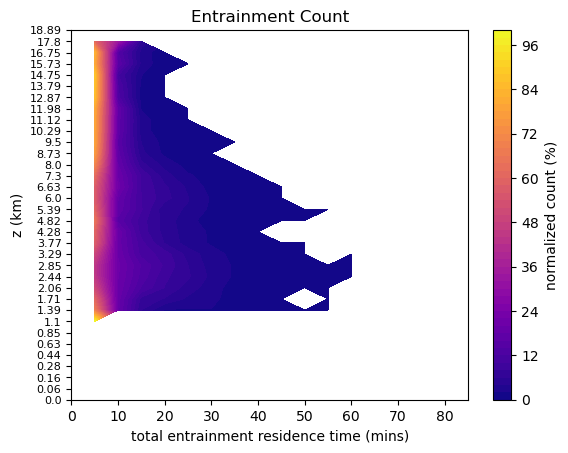

In [18]:
residence_profile=profile.copy() #save for comparing with TKE later


#Nan out zeros
cmap='plasma'
profile2=profile.copy()
profile2[profile2==0]=np.nan


#PLOTTING
# plt.imshow(profile.T);plt.gca().invert_yaxis()
plt.contourf(profile2*100,cmap=cmap,levels=50)

cbar=plt.colorbar(label='normalized count (%)')
plt.ylabel('z (km)');plt.xlabel('total entrainment residence time (mins)')
plt.title('Entrainment Count')

#FIXING TICKS

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);


In [19]:
ts
for ind,(z,l) in enumerate(zip(zs,lens)):
    print(ind,z,l)

0 20 1
1 21 3


In [ ]:
# # Loading Important Variables
# ##############
# if 'emptylike' not in globals():
#     print('loading neccessary variables')
#     variable='w'; w_data=data[variable] #get w data
#     w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
#     variable='qv'; qv_data=data[variable].data # get qc data
#     variable='qc'; qc_data=data[variable].data # get qc data
#     variable='qi'; qi_data=data[variable].data # get qc data
#     qc_plus_qi=qc_data+qi_data
#     buoyancy_data=data['buoyancy'].data

#     import h5py
#     with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}'+'.h5', 'r') as f:
#         theta_e_data = f['theta_e'][:]
    
#     print('done')
#     empty_like=True

In [ ]:
# def call_variables(t): 
#     if np.mod(t,25)==0: print(f'loading variables for time {t}')
#     variable='w'; w_data=data[variable].isel(time=t).interp(zf=data['zh']).data #get w_data and interpolation w data z coordinate from zh to zf
#     variable='qv'; qv_data=data[variable].isel(time=t).data # get qc data
#     variable='qc'; qc_data=data[variable].isel(time=t).data # get qc data
#     variable='qi'; qi_data=data[variable].isel(time=t).data # get qc data
#     qc_plus_qi=qc_data+qi_data
#     variable='th'; th_data=data[variable].isel(time=t).data # get qc data
#     variable='buoyancy'; buoyancy_data=data[variable].isel(time=t).data # get qc data
    
#     import h5py
#     with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}'+'.h5', 'r') as f:
#         theta_e_data = f['theta_e'][t]
        
#     if np.mod(t,25)==0:print(f'done loading')

#     return w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data

In [20]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e',updraft_type='cloudy')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        
        for ind,(z,l) in enumerate(zip(zs,lens)): 
            profile[z,l]+=w_data[ts[ind],zs[ind],ys[ind],xs[ind]] #USE IF LOADING IN FULL VARIABLE
            # t=ts[ind];variable='w'; w_data=data[variable].isel(time=t).interp(zf=data['zh']).data #get w_data and interpolation w data z coordinate from zh to zf #THIS IS WAY TOO SLOW
            # profile[z,l]+=w_data[zs[ind],ys[ind],xs[ind]]
            counter[z,l]+=1

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

NameError: name 'w_data' is not defined

In [ ]:
cmap='plasma'
profile[profile==0]=np.nan
plt.contourf(profile,cmap=cmap,levels=50)
plt.colorbar(label='w (m/s) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrained W Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);


plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

In [ ]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e',updraft_type='cloudy')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        
        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=theta_e_data[ts[ind],zs[ind],ys[ind],xs[ind]] #USE IF LOADING IN FULL VARIABLE
            # t=ts[ind];import h5py #     with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}'+'.h5', 'r') as f: #         theta_e_data = f['theta_e'][t] #THIS IS WAY TOO SLOW
            # profile[z,l]+=theta_e_data[zs[ind],ys[ind],xs[ind]]
            counter[z,l]+=1

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

In [ ]:
cmap='viridis'
profile[profile==0]=np.nan

plt.contourf(profile,cmap=cmap,levels=50)#,vmin=200)
plt.colorbar(label='theta_e (K) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title(r'Entrained $\theta_e$ Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);


In [21]:
#Loading Some Data
tke_data=data['tke'].interp(zf=data['zh']).data

In [22]:
Nz=len(data['zh'])
profile=np.zeros((Nz,18)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e',updraft_type='cloudy')
    if np.any(out)==True:
        lens=out[0]
        # print(lens)
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        
        for ind,(z,l) in enumerate(zip(zs,lens)):
            profile[z,l]+=tke_data[ts[ind],zs[ind],ys[ind],xs[ind]] #USE IF LOADING IN FULL VARIABLE
            # t=ts[ind];tke_data=data['tke'].isel(time=t).interp(zf=data['zh']).data
            # profile[z,l]+=tke_data[zs[ind],ys[ind],xs[ind]]
            counter[z,l]+=1

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

/tmp/ipykernel_542334/480028002.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


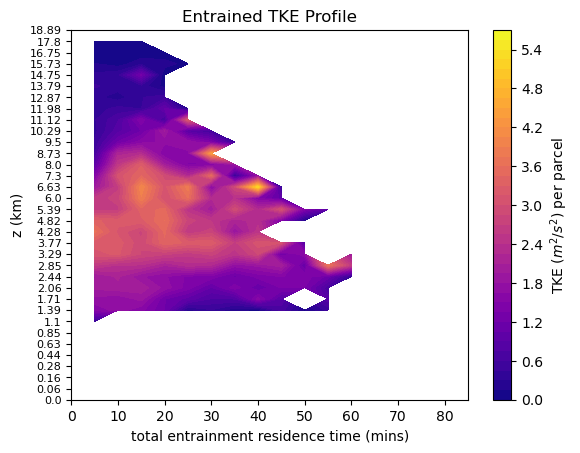

In [23]:
TKE_profile=profile.copy()

cmap='plasma'
profile[profile==0]=np.nan

plt.contourf(profile,cmap=cmap, levels=50)
plt.colorbar(label=r'TKE ($m^2/s^2$) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrained TKE Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

/tmp/ipykernel_542334/1324642050.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


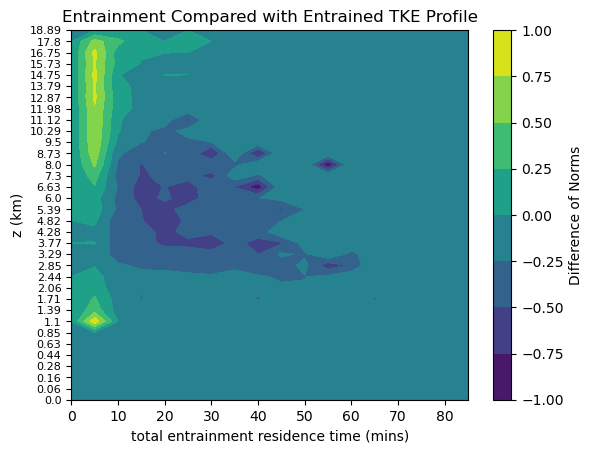

In [24]:
#TESTING TESTING TESTING


TKE_norm = (TKE_profile - np.min(TKE_profile)) / (np.max(TKE_profile) - np.min(TKE_profile))
residence_norm = (residence_profile - np.min(residence_profile)) / (np.max(residence_profile) - np.min(residence_profile))

compare_array = (1-TKE_norm) - (1-residence_norm)



plt.contourf(compare_array)
plt.colorbar(label='Difference of Norms')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrainment Compared with Entrained TKE Profile')

####

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);